In [1]:
import sqlite3
import json
import pandas as pd

# Path to your database
DB_PATH = 'db/results.sqlite'

def verify_database_integrity():
    print(f"Checking database: {DB_PATH}...\n")
    
    try:
        conn = sqlite3.connect(DB_PATH)
        conn.row_factory = sqlite3.Row
        
        # 1. Fetch the most recent result
        cursor = conn.execute("SELECT * FROM Results ORDER BY result_id DESC LIMIT 1")
        row = cursor.fetchone()
        
        if row is None:
            print("❌ Database is empty! Run an experiment first.")
            return

        print(f"✅ Connection successful. Inspecting Result ID: {row['result_id']}\n")

        # --- CHECK 1: OLD DATA (Scalars & Text) ---
        print("--- [1/3] Verifying Legacy Data ---")
        old_keys = ['uq_mech_score', 'uq_avg_entropy', 'full_trace_text', 'predicted_answer']
        
        all_old_ok = True
        for key in old_keys:
            val = row[key]
            if val is not None and val != "":
                print(f"  ✅ {key}: {str(val)[:50]}...")
            else:
                print(f"  ❌ {key} is MISSING or EMPTY!")
                all_old_ok = False
        
        # --- CHECK 2: NEW DATA (Traces & Counts) ---
        print("\n--- [2/3] Verifying New Token-Level Data ---")
        new_keys = ['uq_mech_trace', 'uq_entropy_trace', 'uq_logit_gap_trace', 'gen_len']
        
        all_new_ok = True
        for key in new_keys:
            val = row[key]
            
            # Special check for 'gen_len' (should be int)
            if key == 'gen_len':
                if isinstance(val, int) and val > 0:
                     print(f"  ✅ {key}: {val} (Integer)")
                else:
                    print(f"  ❌ {key}: Invalid or missing integer ({val})")
                    all_new_ok = False
                continue
            
            # Check JSON lists
            try:
                parsed = json.loads(val)
                if isinstance(parsed, list) and len(parsed) > 0:
                    print(f"  ✅ {key}: Found list with {len(parsed)} items. First item: {parsed[0]:.4f}")
                    
                    # Consistency Check
                    if len(parsed) != row['gen_len']:
                        print(f"     ⚠️ WARNING: Trace length ({len(parsed)}) != gen_len ({row['gen_len']})")
                else:
                    print(f"  ❌ {key}: JSON parsed but empty or not a list.")
                    all_new_ok = False
            except TypeError:
                 print(f"  ❌ {key}: Value is None/Null. Did you delete the old DB file?")
                 all_new_ok = False
            except json.JSONDecodeError:
                print(f"  ❌ {key}: Malformed JSON.")
                all_new_ok = False

        # --- CHECK 3: COLUMN EXISTENCE ---
        # Double check the schema actually has the columns
        print("\n--- [3/3] Schema Validation ---")
        columns = [description[0] for description in cursor.description]
        missing_cols = [k for k in new_keys if k not in columns]
        
        if not missing_cols:
            print("  ✅ All new columns exist in table schema.")
        else:
            print(f"  ❌ Missing columns in DB schema: {missing_cols}")

        print("\n" + "="*40)
        if all_old_ok and all_new_ok and not missing_cols:
            print("🎉 SUCCESS: Database schema and data logging are correct!")
        else:
            print("⚠️ ISSUES DETECTED: See errors above.")
            
    except sqlite3.OperationalError as e:
        print(f"❌ SQL Error: {e}")
        print("   (Did you delete the old .sqlite file before running the new code?)")
    finally:
        if 'conn' in locals(): conn.close()

# Run the check
verify_database_integrity()

Checking database: db/results.sqlite...

✅ Connection successful. Inspecting Result ID: 68

--- [1/3] Verifying Legacy Data ---
  ✅ uq_mech_score: 0.9667184540719697...
  ✅ uq_avg_entropy: 0.09753257216829242...
  ✅ full_trace_text:  To determine how much money Mike will have left a...
  ✅ predicted_answer: 800...

--- [2/3] Verifying New Token-Level Data ---
  ✅ uq_mech_trace: Found list with 330 items. First item: 0.9263
  ✅ uq_entropy_trace: Found list with 330 items. First item: -0.0000
  ✅ uq_logit_gap_trace: Found list with 330 items. First item: 1000000.0000
  ✅ gen_len: 330 (Integer)

--- [3/3] Schema Validation ---
  ✅ All new columns exist in table schema.

🎉 SUCCESS: Database schema and data logging are correct!


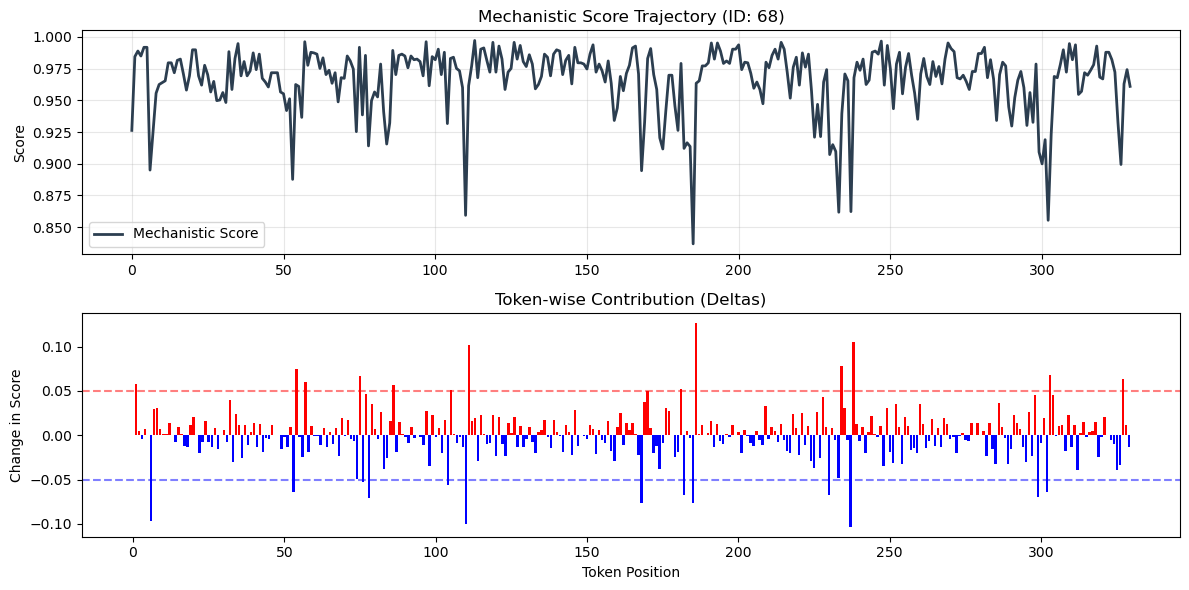


=== MAJOR SPIKES (> 0.05) ===
Pos   | Delta    | Score    | Approx Word
---------------------------------------------
1     | +0.0581 🔺 | 0.9844   | "To"
6     | -0.0967 🔻 | 0.8950   | "Mike"
53    | -0.0635 🔻 | 0.8877   | "ratio"
54    | +0.0747 🔺 | 0.9624   | "between"
57    | +0.0596 🔺 | 0.9961   | "Johnson"
75    | +0.0664 🔺 | 0.9917   | "gets"
76    | -0.0532 🔻 | 0.9385   | "5"
78    | -0.0713 🔻 | 0.9141   | "**Calculate"
86    | +0.0571 🔺 | 0.9893   | ""
104   | -0.0562 🔻 | 0.9316   | "out"
105   | +0.0513 🔺 | 0.9829   | "what"
110   | -0.1006 🔻 | 0.8594   | ""
111   | +0.1021 🔺 | 0.9614   | ""
168   | -0.0762 🔻 | 0.8945   | "$200"
170   | +0.0503 🔺 | 0.9829   | "a"
181   | +0.0527 🔺 | 0.9790   | ""
182   | -0.0669 🔻 | 0.9121   | ""
185   | -0.0767 🔻 | 0.8369   | ""
186   | +0.1265 🔺 | 0.9634   | "\text{Money"


In [2]:
import sqlite3
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIG ---
DB_PATH = 'db/results.sqlite'
THRESHOLD = 0.05  # Highlight jumps larger than this (positive or negative)

def analyze_trace_spikes(result_id=None):
    conn = sqlite3.connect(DB_PATH)
    conn.row_factory = sqlite3.Row
    
    # 1. Fetch Data
    if result_id:
        query = "SELECT * FROM Results WHERE result_id = ?"
        params = (result_id,)
    else:
        query = "SELECT * FROM Results ORDER BY result_id DESC LIMIT 1"
        params = ()
        
    row = conn.execute(query, params).fetchone()
    conn.close()
    
    if not row:
        print("No data found.")
        return

    # 2. Parse JSON Traces
    try:
        mech_trace = json.loads(row['uq_mech_trace'])
        # Optional: Load others if needed
        # entropy_trace = json.loads(row['uq_entropy_trace'])
    except TypeError:
        print(f"Result {row['result_id']} does not have trace data (Legacy row?).")
        return

    # 3. Calculate Deltas (Spikes)
    # Delta[i] = Score[i] - Score[i-1]
    deltas = [0] + [mech_trace[i] - mech_trace[i-1] for i in range(1, len(mech_trace))]
    
    # 4. Visualization: The "Spike Graph"
    plt.figure(figsize=(12, 6))
    
    # Plot Raw Score
    plt.subplot(2, 1, 1)
    plt.plot(mech_trace, label='Mechanistic Score', color='#2c3e50', linewidth=2)
    plt.title(f"Mechanistic Score Trajectory (ID: {row['result_id']})")
    plt.ylabel("Score")
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Plot Deltas (The Spikes)
    plt.subplot(2, 1, 2)
    plt.bar(range(len(deltas)), deltas, color=['red' if d > 0 else 'blue' for d in deltas])
    plt.axhline(y=THRESHOLD, color='r', linestyle='--', alpha=0.5)
    plt.axhline(y=-THRESHOLD, color='b', linestyle='--', alpha=0.5)
    plt.title("Token-wise Contribution (Deltas)")
    plt.ylabel("Change in Score")
    plt.xlabel("Token Position")
    plt.tight_layout()
    plt.show()

    # 5. Text Alignment (Heuristic)
    # Since we didn't save the token list strings, we approximate by splitting the text.
    # Note: This might slightly misalign if the tokenizer splits words differently than spaces.
    text = row['full_trace_text']
    # A simple whitespace split is often "close enough" for inspection, 
    # but strictly speaking, the traces align with BPE tokens, not words.
    words = text.split(" ") 
    
    print(f"\n=== MAJOR SPIKES (> {THRESHOLD}) ===")
    print(f"{'Pos':<5} | {'Delta':<8} | {'Score':<8} | {'Approx Word'}")
    print("-" * 45)
    
    # We iterate up to min length to avoid index errors if splitting mismatches BPE
    limit = min(len(words), len(deltas))
    
    for i in range(limit):
        if abs(deltas[i]) >= THRESHOLD:
            indicator = "🔺" if deltas[i] > 0 else "🔻"
            print(f"{i:<5} | {deltas[i]:+.4f} {indicator} | {mech_trace[i]:.4f}   | \"{words[i]}\"")

# --- RUN IT ---
# Analyze the most recent generation
analyze_trace_spikes()